> # FEATURE CONSTRUCTION
Feature construction is defiened as: ***the process of using domain knowledge to create new input variables (features) form raw data that make machine learning algorithms work better***

It involves creating new features from the existing dataset to help machine learning modles better capture relationships between variables. Unlike other feature engineering techniques, feature construction heavily relies on **domain expertise and intuition**

---

> ## The Mathematical Objective
If your raw data is $X$ and the target is $y$, you are trying to find a transformation function $\phi$ such that:
$$New\text{ Feature} = \phi(X_1, X_2,...X_n)$$

The goal is to make the relationship between $\phi( \text{X})$ and $y$ **more linear** or **more separable** than the relationship between raw $X$ and $y$

---
### The 4 Core "Lenses" of Feature Construction
- <font color = 'gray'>The Magnitude Lense (Arithmetic)</font>: Creating features that capture size or proportion
  - Examples: Sum, Difference, Ratio, Product
  - Ratios are powerful because they remove scale dependency (e.g., Revenue per Customer is more informative than raw Revenue)
- <font color = 'gray'>The Aggregation Lense (Statistical)</font>: Grouping raw data points to create stable, high-level signals
  - Examples: Mean, Median, Standard Deviation, Min, Max, Count
  - This reduces overfitting by moving from individual noisy data points to population-level tendencies (e.g., Average purchase amount in the last 7 days)
- <font color = 'gray'>The Interaction Lense (Polynomial/Crossing)</font>: Capturing the synergy between two or more features
  - Examples: Multiplying $Age \times Income$, or creating "Morning" flag by crossing $Hour \times Weekday$
  - If the effect of Feature A on the target depends on Feature B, you must construct an interaction term
- <font color = 'gray'>The Temporal Lense (Lag/Window)</font>: Encoding time-dependent behavior
  - Examples: Rolling averages, Time since last event, Day-of-week sine/cosine encoding
  - Recent beahvior is usually more predictive than distant behavior (exponential decay windows)

---

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [57]:
df = pd.read_csv('train.csv', usecols = ['Age','Pclass', 'SibSp', 'Parch', 'Survived'])
df.shape

(891, 5)

In [58]:
df_raw = df.copy()
df_raw.shape

(891, 5)

In [59]:
df_raw.head()

,Survived,Pclass,Age,SibSp,Parch
0,0,3,22.0,1,0
1,1,1,38.0,1,0
2,1,3,26.0,0,0
3,1,1,35.0,1,0
4,0,3,35.0,0,0


In [60]:
df_raw.isnull().mean()

Survived    0.000000
Pclass      0.000000
Age         0.198653
SibSp       0.000000
Parch       0.000000
dtype: float64

In [61]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 34.9 KB


In [62]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.000,0.0,1.0,1.0
Pclass,891.0,2.308642,0.836071,1.00,2.000,3.0,3.0,3.0
Age,714.0,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,0.523008,1.102743,0.00,0.000,0.0,1.0,8.0
Parch,891.0,0.381594,0.806057,0.00,0.000,0.0,0.0,6.0


<Axes: xlabel='Age', ylabel='Density'>

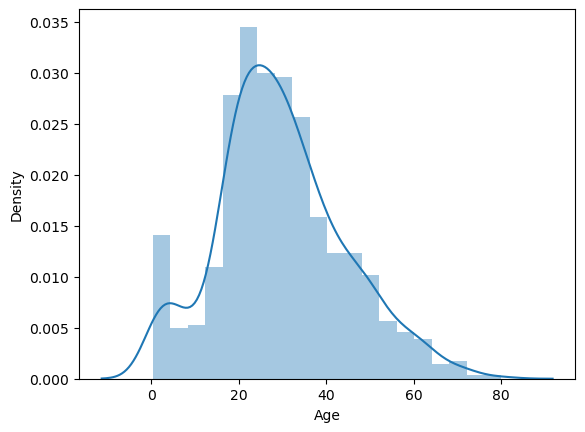

In [63]:
sns.distplot(df_raw['Age'])

In [64]:
df_raw['Age'].skew()

np.float64(0.38910778230082704)

In [65]:
X = df_raw.drop(columns = ['Survived'])
y = df.Survived

In [66]:
X.isnull().mean()

Pclass    0.000000
Age       0.198653
SibSp     0.000000
Parch     0.000000
dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

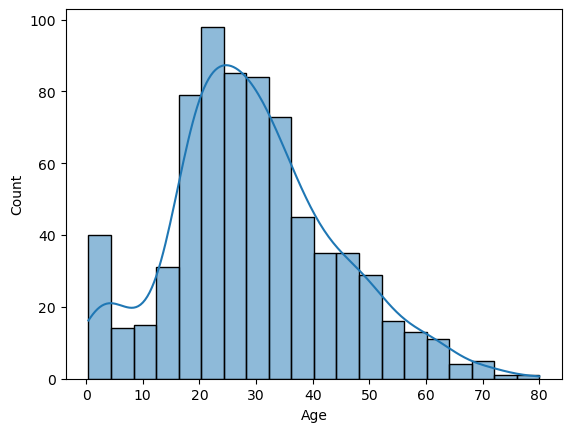

In [67]:
sns.histplot(X['Age'], kde = True)

In [90]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy = 'median')
si.set_output(transform = 'pandas')

X_imputed = si.fit_transform(X)
X_imputed.isnull().mean()

Pclass    0.0
Age       0.0
SibSp     0.0
Parch     0.0
dtype: float64

In [91]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

np.mean(cross_val_score(LogisticRegression(), X_imputed, y, scoring = 'accuracy', cv = 20))

np.float64(0.6994444444444444)

### Applying Feature Construction

In [92]:
X_imputed['Family_size'] = X_imputed['SibSp'] + X_imputed['Parch'] + 1
X_imputed.tail()

,Pclass,Age,SibSp,Parch,Family_size
886,2.0,27.0,0.0,0.0,1.0
887,1.0,19.0,0.0,0.0,1.0
888,3.0,28.0,1.0,2.0,4.0
889,1.0,26.0,0.0,0.0,1.0
890,3.0,32.0,0.0,0.0,1.0


In [93]:
def family_type(num):
    if num == 1:
        return 0 # 0 indicates alone
    elif num > 1 and num <= 4:
        return 1 # 1 indicates small family 
    else:
        return 2 # 2 indicates large family 

In [94]:
family_group(5)

2

In [95]:
X_imputed['Family_type'] = X_imputed['Family_size'].apply(family_type)
X_imputed.tail()

,Pclass,Age,SibSp,Parch,Family_size,Family_type
886,2.0,27.0,0.0,0.0,1.0,0
887,1.0,19.0,0.0,0.0,1.0,0
888,3.0,28.0,1.0,2.0,4.0,1
889,1.0,26.0,0.0,0.0,1.0,0
890,3.0,32.0,0.0,0.0,1.0,0


In [96]:
# X_imputed.drop(columns = ['SibSp', 'Parch', 'Family_size'], inplace = True)

In [97]:
X_imputed.head()

,Pclass,Age,SibSp,Parch,Family_size,Family_type
0,3.0,22.0,1.0,0.0,2.0,1
1,1.0,38.0,1.0,0.0,2.0,1
2,3.0,26.0,0.0,0.0,1.0,0
3,1.0,35.0,1.0,0.0,2.0,1
4,3.0,35.0,0.0,0.0,1.0,0


In [98]:
np.mean(cross_val_score(LogisticRegression(), X_imputed, y, scoring = 'accuracy', cv = 20))

np.float64(0.7130555555555556)

In [99]:
X_imputed['IsAlone'] = (X_imputed['Family_size'] == 1).astype(int)
X_imputed.head()

,Pclass,Age,SibSp,Parch,Family_size,Family_type,IsAlone
0,3.0,22.0,1.0,0.0,2.0,1,0
1,1.0,38.0,1.0,0.0,2.0,1,0
2,3.0,26.0,0.0,0.0,1.0,0,1
3,1.0,35.0,1.0,0.0,2.0,1,0
4,3.0,35.0,0.0,0.0,1.0,0,1


In [101]:
np.mean(cross_val_score(LogisticRegression(), X_imputed, y, scoring = 'accuracy', cv = 20))

np.float64(0.7344191919191918)

In [132]:
bins = [0, 12, 19, 40, 100]
labels = ['Child (0-12)', 'Teen (13-19)', 'Adult (20-40)', 'Senior (40+)']
X_imputed['AgeGroup'] = pd.cut(X_imputed['Age'], bins = bins, labels = labels, right = False)

In [135]:
X_imputed['AgeGroup'].value_counts().sort_index()

AgeGroup
Child (0-12)      68
Teen (13-19)      71
Adult (20-40)    589
Senior (40+)     163
Name: count, dtype: int64

In [133]:
X_imputed[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,22.0,Adult (20-40)
1,38.0,Adult (20-40)
2,26.0,Adult (20-40)
3,35.0,Adult (20-40)
4,35.0,Adult (20-40)


### Feature Splitting

In [139]:
df = pd.read_csv('train.csv')
df.shape

(891, 12)

In [140]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [141]:
df_sp = df.copy()

In [142]:
df_sp.shape

(891, 12)

In [143]:
df_sp['Title'] = df_sp['Name'].str.split(',', expand = True)[1].str.split('.', expand = True)[0].str.strip()

In [144]:
df_sp.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [145]:
df_sp[['Title', 'Name']]

,Title,Name
0,Mr,"Braund, Mr. Owen Harris"
1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,Miss,"Heikkinen, Miss. Laina"
3,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,Mr,"Allen, Mr. William Henry"
...,...,...
886,Rev,"Montvila, Rev. Juozas"
887,Miss,"Graham, Miss. Margaret Edith"
888,Miss,"Johnston, Miss. Catherine Helen ""Carrie"""
889,Mr,"Behr, Mr. Karl Howell"


In [146]:
df_sp.groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
Lady            1.000000
Ms              1.000000
Sir             1.000000
Mme             1.000000
the Countess    1.000000
Mlle            1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Major           0.500000
Col             0.500000
Dr              0.428571
Mr              0.156673
Capt            0.000000
Jonkheer        0.000000
Don             0.000000
Rev             0.000000
Name: Survived, dtype: float64

In [150]:
df_sp['IsMarried'] = 0
df_sp['IsMarried'].loc[df_sp['Title'] == 'Mrs'] = 1

In [152]:
df_sp[['Title', 'IsMarried']].sample(10)

,Title,IsMarried
32,Miss,0
131,Mr,0
816,Miss,0
602,Mr,0
797,Mrs,1
123,Miss,0
331,Mr,0
249,Rev,0
107,Mr,0
739,Mr,0


In [154]:
df_sp.groupby('IsMarried')['Survived'].mean().sort_values(ascending = False)

IsMarried
1    0.792000
0    0.317232
Name: Survived, dtype: float64